# **Pathway Analysis**

# **Introduction**

Finally, in this file you will find the end of our investigation where we used the best performing model cross-cellline and cross-technology to investigate **biological pathways** with the **Over-Representation 
Analysis** method. 

## **Python Libraries**

In [1]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
import gseapy as gp # gene set enrichment analysis
from gseapy import dotplot, barplot
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from joblib import dump
from joblib import load


/Users/bianca/AILAB/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# **Extracting Features from Best-Performing Model**

To biologically interpret the predictive model, the top 150 genes ranked by feature importance were extracted from the best-performing classifier across all four datasets, spanning two sequencing technologies and two cell lines. Over-representation analysis (ORA) was then performed using the full MSigDB Hallmark gene set collection rather than testing only hypoxia-associated pathways, in order to reduce interpretational bias and allow biologically relevant pathways to emerge naturally from the data.

After carefull inspection of the predictive performance of the 20 models trained throughout our investigation (5 Algorithms x 4 Training Sets), we came to the conclusion that the **Logistic Regression Model** trained with the **HCC1806-SmartSeq dataset** was our best-performing classifier. Across all datasets, it attained the following average scores: 84.4% accuracy, 87.1% precision, 79.2% recall, 81.6% F1, and 90.6% AUC. 

Therefore, we proceed with importing the model.

In [2]:
model = load("/Users/bianca/Desktop/LR_model.joblib")
X_train = pd.read_csv("/Users/bianca/Desktop/X_train.csv", index_col=0)

In a logistic regression model, feature importance can be estimated using the absolute values of the model coefficients, where larger coefficients indicate a stronger influence on the prediction. By ranking the coefficients by magnitude, we can extract the top 150 most important features (genes) that contribute most to distinguishing between hypoxic and normoxic cells. 

In [3]:
importance_df = pd.DataFrame({"gene": X_train.columns, "importance": abs(model.coef_[0])})
importance_df = importance_df.sort_values( by="importance", ascending=False)
selected_genes = importance_df.head(150)["gene"]
print("Most Important Genes:\n", importance_df.head(150))

Most Important Genes:
             gene  importance
62         BNIP3    0.001987
1141       P4HA1    0.001080
1        ANGPTL4    0.001018
299       PFKFB3    0.000963
101       SLC2A1    0.000893
...          ...         ...
2003       LYPD5    0.000000
2017  PALM2AKAP2    0.000000
1910  FAM193B-DT    0.000000
2991      ZYG11A    0.000000
2050   LINC00571    0.000000

[150 rows x 2 columns]


## **Over-Representation Analysis (ORA)**

Proceeding with the Over-Representation Analysis (ORA), our top 150 most important genes identified from the model were tested for enrichment against the full MSigDB Hallmark gene set collection. 

ORA evaluates whether specific biological pathways or gene sets are represented more frequently in the selected gene list than would be expected by random chance. 

The MSigDB Hallmark collection is a curated set of 50 gene sets that summarize well-defined biological states and processes while reducing redundancy between pathways. Using the full MSigDB Hallmark collection rather than focusing exclusively on hypoxia-related pathways helps reduce analytical bias by allowing all major biological processes to be evaluated equally, ensuring that any enrichment observed emerges from the data itself rather than from prior expectations.

In [4]:
enr = gp.enrichr( gene_list=selected_genes, gene_sets="/Users/bianca/Desktop/h.all.v2026.1.Hs.symbols.gmt", organism="human", outdir=None)
results = enr.results.sort_values("Adjusted P-value")
results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
18,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_HYPOXIA,19/200,3.016150e-08,0.000001,5.770053,99.918283,MIF;NDRG1;ANGPTL4;PPP1R15A;FAM162A;FOS;IGFBP3;...
27,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_MTORC1_SIGNALING,17/200,8.965996e-07,0.000020,4.988893,69.468615,LDHA;ERO1A;BHLHE40;P4HA1;PGK1;SLC1A5;PRDX1;DDI...
15,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_GLYCOLYSIS,14/200,8.309550e-05,0.001219,3.914587,36.779584,ERO1A;MIF;P4HA1;PGK1;DDIT4;CD44;HSPA5;TXN;IGFB...
35,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,6/49,5.825849e-04,0.006408,7.089771,52.804865,NQO1;FTL;PRDX1;GPX3;TXN;PRNP
38,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_TNFA_SIGNALING_VIA_NFKB,12/200,1.129519e-03,0.008283,3.257279,22.103772,BHLHE40;FOSL1;PHLDA1;NFKBIA;CD44;FOS;SERPINB2;...
11,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_ESTROGEN_RESPONSE_EARLY,12/200,1.129519e-03,0.008283,3.257279,22.103772,KRT18;SFN;BHLHE40;KRT13;FDFT1;KRT8;CD44;FOS;SL...
31,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_P53_PATHWAY,11/200,3.638910e-03,0.022873,2.944888,16.538698,SFN;NDRG1;DDIT4;FOS;ZFP36L1;SLC3A2;BLCAP;PPP1R...
12,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_ESTROGEN_RESPONSE_LATE,10/200,1.064656e-02,0.052050,2.642768,12.004824,SFN;FDFT1;KRT13;CD44;FOS;LAMC2;SLC7A5;CDC20;KR...
19,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_IL2_STAT5_SIGNALING,10/199,1.029618e-02,0.052050,2.657362,12.160044,BHLHE40;ITGA6;APLP1;PHLDA1;SLC1A5;P4HA1;NDRG1;...
41,h.all.v2026.1.Hs.symbols.gmt,HALLMARK_UV_RESPONSE_UP,8/158,2.032024e-02,0.089409,2.671913,10.410140,SLC6A8;CCK;GPX3;NFKBIA;FOS;ALDOA;SQSTM1;TFRC


Overall, the enrichment results strongly support that the model is learning a hypoxia-associated transcriptional programme, as the most significantly overrepresented pathways are dominated by hypoxia, glycolysis, mTORC1 signalling, and other stress-response processes classically linked to cellular adaptation to low-oxygen conditions. Still, in order to better interpret these results, the top enriched pathways are summarized using a bubble plot.

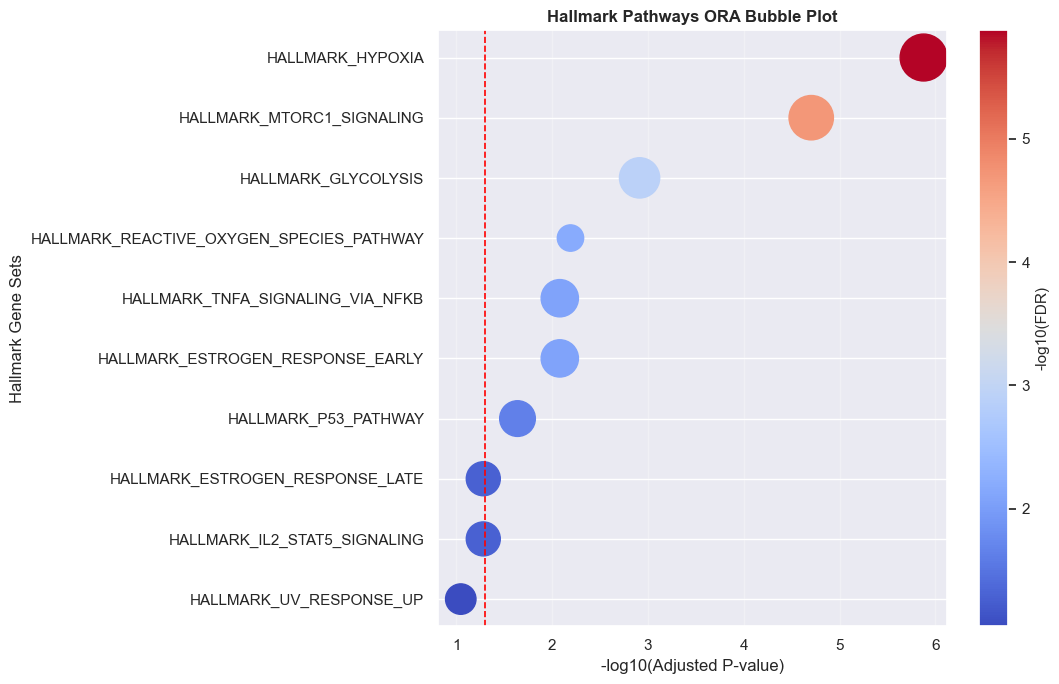

In [8]:
results["Adjusted P-value"] = pd.to_numeric(results["Adjusted P-value"])
results["Combined Score"] = pd.to_numeric(results["Combined Score"])
results["minus_log10_fdr"] = -np.log10(results["Adjusted P-value"])
results["overlap_count"] = (results["Overlap"].str.split("/").str[0].astype(int))
results["gene_set_size"] = (results["Overlap"].str.split("/").str[1].astype(int))
results["percent_overlap"] = (results["overlap_count"] / 200) * 100
top = results.head(10)
top = top.iloc[::-1]
plt.figure(figsize=(11, 7))
scatter = plt.scatter(x=top["minus_log10_fdr"], y=top["Term"],s=top["percent_overlap"] * 120, c=top["minus_log10_fdr"], cmap="coolwarm",)

plt.xlabel("-log10(Adjusted P-value)")
plt.ylabel("Hallmark Gene Sets")
plt.title("Hallmark Pathways ORA Bubble Plot",weight="bold")

cbar = plt.colorbar(scatter)
cbar.set_label("-log10(FDR)", fontsize=11)

plt.axvline(-np.log10(0.05),linestyle="--",linewidth=1.2,color="red")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/bianca/Desktop/ORABubblePlot.png", dpi=300, bbox_inches='tight')
plt.show()

The enrichment analysis revealed a highly significant over-representation of the HALLMARK_HYPOXIA gene set (19 out of 200 genes overlapped, approximately 1.0 × 10⁻⁶ adjusted p-value, and 99.9 combined enrichment score). This suggests that the classifier successfully learned gene expression patterns linked to low oxygen conditions, rather than simply picking up dataset-specific patterns or noise. Overall, this provides strong evidence that the machine learning model captured biologically meaningful features associated with hypoxia.

Alongside the hypoxia pathway itself, several pathways linked to metabolic adaptation and cellular stress responses were also strongly overrepresented. In particular, HALLMARK_GLYCOLYSIS (14/200 genes overlapped, approximate adjusted p-value of 1.2 × 10⁻³) and HALLMARK_MTORC1_SIGNALING (17/200 genes overlapped, approximate adjusted p-value of 2.0 × 10⁻⁴) were among the most significant pathways.This matches what is already known about hypoxia biology, where cells shift towards glycolysis when oxygen levels are low and oxidative phosphorylation becomes less efficient. Additionally, overrepresentation of the HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY and HALLMARK_TNFA_SIGNALING_VIA_NFKB pathways further suggest that oxidative stress and inflammatory signalling are important parts of the transcriptional profile captured by our classifier. Together, these findings support the idea that the predictive model reflects coordinated hypoxia-induced metabolic and stress adaptation programs.

Other overrepresented pathways, including HALLMARK_P53_PATHWAY, HALLMARK_G2M_CHECKPOINT, HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION (EMT), and HALLMARK_APICAL_JUNCTION, are   related to tumour progression and cellular regulation. These findings are biologically relevant in the context of our investigation as hypoxia is known to affect cell-cycle control, genomic stability, invasion, and metastatic behaviour. 

The EMT signal is especially interesting, as it may indicate that the model captures not only hypoxia responses but also transcriptional programs linked to more aggressive tumour behaviour. Lastly, although HALLMARK_ESTROGEN_RESPONSE_EARLY was also enriched, this may partly reflect the biology of the MCF7 breast cancer cell line included in the analysis, as well as known interactions between hypoxia and hormone signalling pathways.

Overall, these results show that the classifier identified a biologically coherent hypoxia-associated transcriptional programme involving oxygen sensing, metabolic adaptation, stress signalling, and tumour progression pathways. Importantly, the strong overlap between the our best-performing model’s most predictive genes and established hypoxia-related pathways improves the interpretability of the machine learning approach and supports the conclusion that the model is detecting genuine hypoxia biology rather than random technical variation.

# **Conclusion**

Our group project provided a rigorous and comprehensive exploration of single-cell gene expression data, with the primary objective of distinguishing hypoxic from normoxic cellular conditions. Throughout this work, we applied a broad range of techniques and methodologies that enabled us to investigate both the technical and biological complexity of the datasets in depth.

The project began with extensive exploratory data analysis (EDA), where we examined data distributions, identified potential sources of variability, and recognized the need for data preprocessing. In parallel, substantial attention was devoted to preprocessing procedures, including filtering low-quality features and samples, normalization, transformation of gene expression values, and feature selection. We also explored the underlying structure of the datasets through dimensionality reduction techniques such as Principal Component Analysis (PCA) and clustering approaches. These preliminary analyses were fundamental in understanding the heterogeneity of the data and in guiding the subsequent modelling strategies.

Building on this foundation, we implemented and compared several supervised machine learning algorithms, including logistic regression, support vector machines (SVMs), random forests, k-nearest neighbours (KNN), and ensemble learning methods. The ensemble learning strategy combined the strengths of multiple classifiers into a unified predictive framework by weighting each model’s contribution according to its F1-score. Each model was carefully optimized and evaluated using multiple performance metrics, including accuracy, F1-score, recall, precision, AUC, and confusion matrices, allowing for a more holistic and reliable interpretation of predictive performance. Additionally, we adopted grid search rather than randomized search in order to perform a more exhaustive hyperparameter optimization and ensure a more rigorous evaluation process.

Furthermore, we investigated the ability of our trained models to generalize across different biological contexts, including distinct cell lines and sequencing technologies. This represented one of the most challenging and insightful components of our study. While several models experienced a significant decrease in performance when transferred across technologies, some retained meaningful predictive capabilities across different cell lines, highlighting both the challenges of domain adaptation in biological datasets and the potential for transferable hypoxia-related transcriptional signatures.

Interestingly, logistic regression consistently emerged as the best-performing and most reliable model overall, despite its relative simplicity compared to the more complex machine learning approaches considered. This suggests that simpler linear models may, in certain biological contexts, possess greater robustness and generalizability across heterogeneous datasets and technical platforms than highly complex algorithms, which can be more susceptible to overfitting technical noise and dataset-specific patterns. Consequently, our results emphasize the importance of balancing model complexity with interpretability and generalizability when working with high-dimensional biomedical data.

Another highly significant outcome of our work was the extraction and interpretation of feature importance from the best-performing model. This enabled us to carry out over-representation analysis (ORA) for broader biological interpretation of both the model and its results. Through this analysis, we were able to investigate whether the model had successfully captured a biologically meaningful hypoxia-associated transcriptional programme, thereby linking computational predictions to underlying molecular mechanisms and cancer biology.

Overall, this project not only strengthened our group’s technical competencies in data analysis, machine learning, and model evaluation, but also deepened our understanding of genomics, cancer biology, and the role of hypoxia in tumour progression and therapeutic resistance. Importantly, it demonstrated how artificial intelligence and computational approaches can be leveraged to extract biologically relevant insights from highly complex biomedical data, reinforcing the interdisciplinary nature of modern biomedical research.